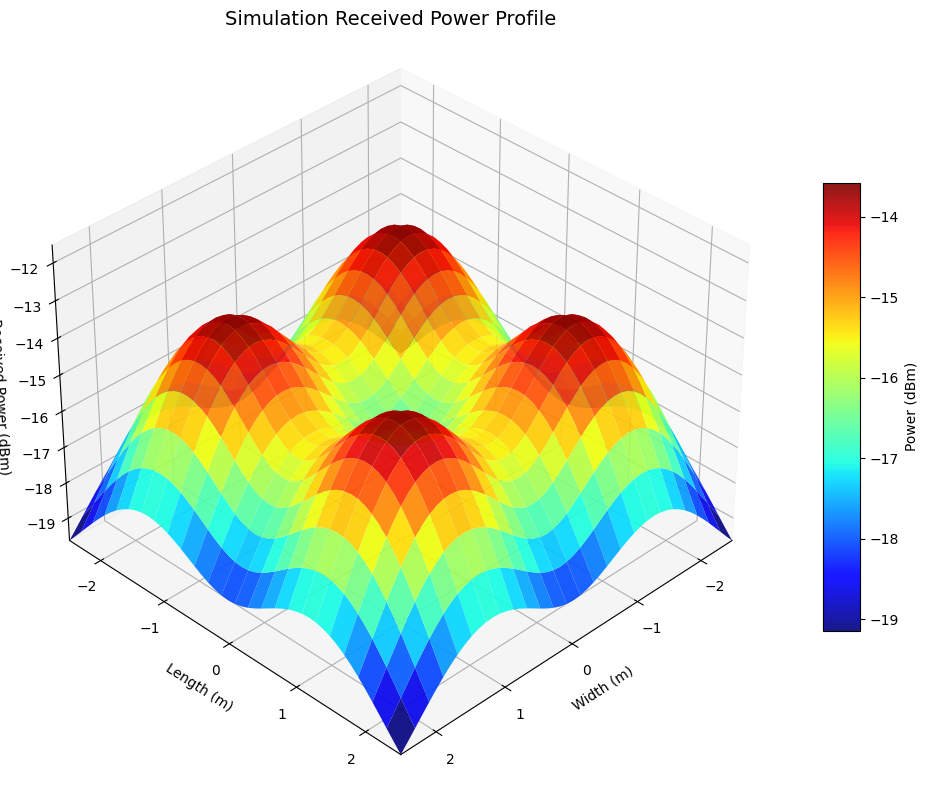

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def simulate_vlp_figure_2():
    """
    Simulates the optical power distribution for a VLP system.
    Reproduces the geometry and parameters described in Figure 2 of the reference paper.
    """
    
    # --- 1. GEOMETRIC PARAMETERS ---
    # Room Dimensions (Length x Width x Height) in meters
    ROOM_L = 5.0
    ROOM_W = 5.0
    ROOM_H = 3.0
    
    # Receiver Grid initialization on the floor plane (z=0)
    grid_step = 0.1  # Spatial resolution: 0.1m
    x = np.arange(-ROOM_L/2, ROOM_L/2 + grid_step, grid_step)
    y = np.arange(-ROOM_W/2, ROOM_W/2 + grid_step, grid_step)
    X, Y = np.meshgrid(x, y)
    Z_RX = 0.0
    
    # --- 2. TRANSMITTER CONFIGURATION (LEDs) ---
    # LED placement: Midpoints of diagonals in each quadrant
    # Coordinates: (+/- 1.25, +/- 1.25, 3.0)
    offset = 1.25
    z_tx = 3.0
    led_positions = (
        [offset, offset, z_tx],    # LED 1 (Quadrant 1)
        [-offset, offset, z_tx],   # LED 2 (Quadrant 2)
        [-offset, -offset, z_tx],  # LED 3 (Quadrant 3)
        [offset, -offset, z_tx]    # LED 4 (Quadrant 4)
    )
    
    # Optical Power Settings
    P_TOTAL = 2.0           # Total system power (Watts)
    P_LED = P_TOTAL / 4.0   # Power per LED (0.5 W)
    
    # --- 3. OPTICAL CHANNEL MODEL ---
    # Lambertian order (m). m=12.5 is selected to replicate the specific beam profile
    # observed in the reference figure (narrower beam than m=1).
    m_order = 12.5          
    
    A_PD = 1e-4             # Photodetector active area (1 cm^2 = 1e-4 m^2)
    Ts = 1.0                # Optical filter gain
    n = 1.5                 # Refractive index of the lens
    FOV_deg = 60.0          # Field of View (degrees)
    FOV_rad = np.deg2rad(FOV_deg)
    rho = 0.8               # Wall reflection coefficient
    
    # Optical Concentrator Gain
    # g = n^2 / sin^2(FOV)
    g_conc = (n**2) / (np.sin(FOV_rad)**2)
    
    # Diffuse Reflection Component (Integrating Sphere Model)
    # Approximates the non-LoS contribution based on room surface area and reflection coefficient.
    area_room = 2 * (ROOM_L*ROOM_W + ROOM_L*ROOM_H + ROOM_W*ROOM_H)
    H_diffuse = (rho * A_PD) / (area_room * (1 - rho))
    
    # --- 4. RECEIVED POWER COMPUTATION ---
    # Initialize total power matrix
    P_total_watts = np.zeros_like(X)
    
    # Superposition of power contributions from each LED
    for led in led_positions:
        lx, ly, lz = led
        
        # Euclidean distance calculation
        dist_sq = (X - lx)**2 + (Y - ly)**2 + (Z_RX - lz)**2
        dist = np.sqrt(dist_sq)
        
        # Geometry: Cosine of irradiance (phi) and incidence (psi) angles
        # Assuming horizontal transmitter and receiver planes: phi = psi
        h = lz - Z_RX
        cos_phi = h / dist
        cos_psi = cos_phi
        
        # Line-of-Sight (LoS) Channel Gain Calculation
        # H_los = [(m+1)A / 2pi*d^2] * cos^m(phi) * Ts * g * cos(psi)
        H_los = ((m_order + 1) * A_PD) / (2 * np.pi * dist_sq) * \
                (cos_phi ** m_order) * \
                Ts * g_conc * cos_psi
        
        # Apply Field of View (FOV) constraints
        # Received power is zero if the angle of incidence exceeds FOV
        psi_angle = np.arccos(np.clip(cos_psi, -1.0, 1.0))
        mask_fov = psi_angle <= FOV_rad
        H_los = H_los * mask_fov
        
        # Total Channel Gain: LoS + Diffuse
        H_total = H_los + H_diffuse
        
        # Accumulate power
        P_total_watts += P_LED * H_total

    # --- 5. SIGNAL PROCESSING (dBm CONVERSION) ---
    # P(dBm) = 10 * log10( P(W) / 1mW )
    # A small epsilon (1e-20) is added to prevent logarithmic singularities.
    P_total_dBm = 10 * np.log10((P_total_watts + 1e-20) * 1000)
    
    # --- 6. VISUALIZATION ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Surface Plot generation
    surf = ax.plot_surface(X, Y, P_total_dBm, cmap='jet', 
                           edgecolor='none', antialiased=True, alpha=0.9)
    
    # Axis labels and plot title
    ax.set_title(f'Simulation Received Power Profile', fontsize=14)
    ax.set_xlabel('Width (m)')
    ax.set_ylabel('Length (m)')
    ax.set_zlabel('Received Power (dBm)')
    
    # Axis limits aligned with the reference paper
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    # Z-axis adjustment for optimal visualization
    z_min = np.min(P_total_dBm)
    z_max = np.max(P_total_dBm)
    ax.set_zlim(z_min, z_max + 2)
    
    # Colorbar configuration
    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, label='Power (dBm)')
    
    # Viewpoint adjustment (Elevation, Azimuth)
    ax.view_init(elev=35, azim=45)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_vlp_figure_2()